In [20]:
!pip install shap fairlearn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import shap
from fairlearn.metrics import demographic_parity_difference
import warnings
warnings.filterwarnings('ignore')

print("✅ Setup complete!")

✅ Setup complete!


In [21]:
# Load data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Create synthetic sensitive feature
np.random.seed(42)
df['sensitive_group'] = np.random.choice(['Group_A', 'Group_B'], size=len(df), p=[0.6, 0.4])

# Train model
X = df[iris.feature_names]
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"✅ Model trained! Accuracy: {model.score(X_test, y_test):.4f}")
print(f"✅ Dataset shape: {df.shape}")

✅ Model trained! Accuracy: 1.0000
✅ Dataset shape: (150, 6)


🔄 Generating SHAP plots...


<Figure size 1000x600 with 0 Axes>

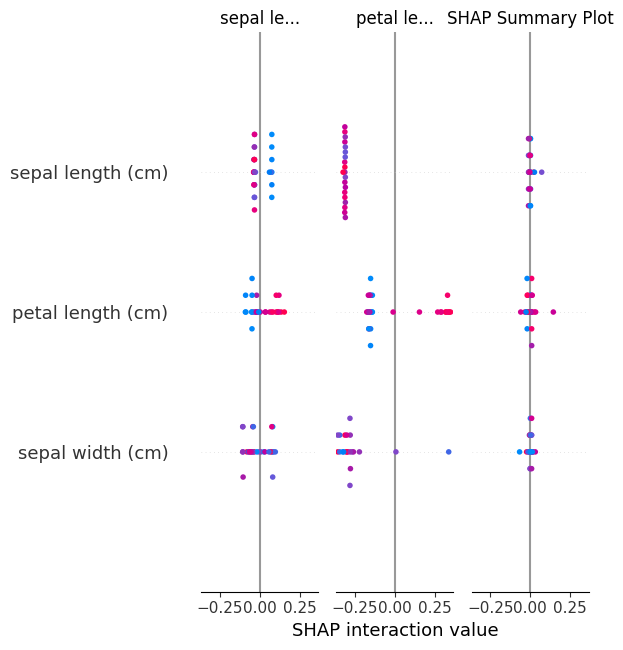

✅ Saved: shap_summary.png


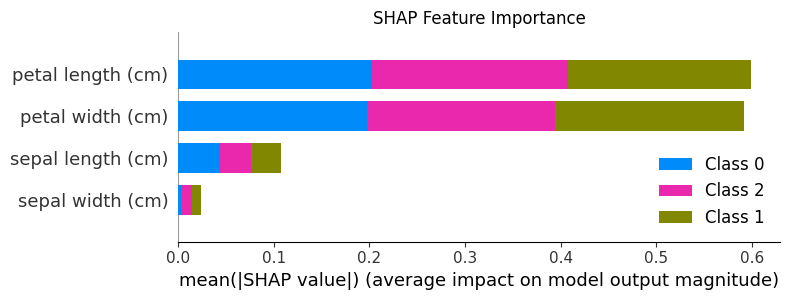

✅ Saved: shap_importance.png


In [22]:
# SHAP Analysis
print("🔄 Generating SHAP plots...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot 1: Summary dot plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=iris.feature_names, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=100)
plt.show()
print("✅ Saved: shap_summary.png")

# Plot 2: Bar plot
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test, feature_names=iris.feature_names, plot_type="bar", show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight', dpi=100)
plt.show()
print("✅ Saved: shap_importance.png")


=== FAIRNESS ASSESSMENT ===
Group A prediction rate: 1.1053
Group B prediction rate: 0.9091

Demographic Parity Difference: 0.1005
Fairness Level: Moderate - Review recommended

=== FEATURE IMPORTANCE ===
          Feature  Importance
petal length (cm)    0.439994
 petal width (cm)    0.421522
sepal length (cm)    0.108098
 sepal width (cm)    0.030387

🔥 Most important: petal length (cm)


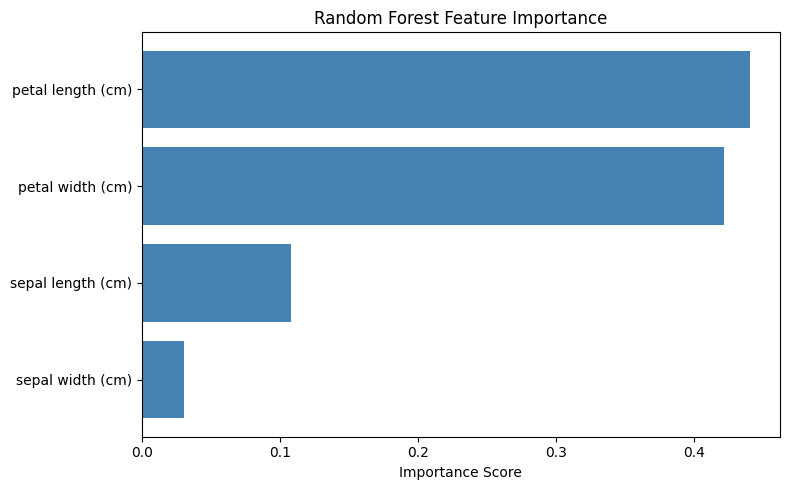

✅ Saved: feature_importance.png


In [23]:
# Fairness Assessment
sensitive_test = df.loc[X_test.index, 'sensitive_group']

pred_df = pd.DataFrame({
    'predicted': y_pred,
    'group': sensitive_test
})

group_rates = pred_df.groupby('group')['predicted'].mean()
print("\n=== FAIRNESS ASSESSMENT ===")
print(f"Group A prediction rate: {group_rates.get('Group_A', 0):.4f}")
print(f"Group B prediction rate: {group_rates.get('Group_B', 0):.4f}")

demographic_diff = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_test
)
print(f"\nDemographic Parity Difference: {demographic_diff:.4f}")

if demographic_diff < 0.05:
    fairness_level = "Excellent"
elif demographic_diff < 0.1:
    fairness_level = "Good"
elif demographic_diff < 0.2:
    fairness_level = "Moderate - Review recommended"
else:
    fairness_level = "Concerning - Mitigation needed"
print(f"Fairness Level: {fairness_level}")

# Feature Importance (using model's built-in importance)
print("\n=== FEATURE IMPORTANCE ===")
feature_importance = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))
print(f"\n🔥 Most important: {feature_importance.iloc[0]['Feature']}")

# Plot feature importance
plt.figure(figsize=(8, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()
print("✅ Saved: feature_importance.png")

In [24]:
# Generate Report
print("\n=== GENERATING REPORT ===\n")

top_feature = feature_importance.iloc[0]['Feature']
top_value = feature_importance.iloc[0]['Importance']
second_feature = feature_importance.iloc[1]['Feature']
second_value = feature_importance.iloc[1]['Importance']
third_feature = feature_importance.iloc[2]['Feature']
third_value = feature_importance.iloc[2]['Importance']

report = f"""
========================================
     RESPONSIBLE AI REPORT
     Alfido Tech Internship - Task 4
========================================

📊 MODEL INFORMATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model Type: Random Forest Classifier
Dataset: Iris (150 samples, 4 features)
Classes: Setosa, Versicolor, Virginica
Accuracy: {model.score(X_test, y_test):.4f} ({model.score(X_test, y_test)*100:.1f}%)

🔍 MODEL INTERPRETABILITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Top 3 Important Features:
1. {top_feature}: {top_value:.4f}
2. {second_feature}: {second_value:.4f}
3. {third_feature}: {third_value:.4f}

Insight: {top_feature} is the most important feature for predictions.

⚖️ FAIRNESS ASSESSMENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Sensitive Groups: Group_A, Group_B (synthetic)
Demographic Parity Difference: {demographic_diff:.4f}
Fairness Level: {fairness_level}

Prediction Rates:
• Group_A: {group_rates.get('Group_A', 0):.4f}
• Group_B: {group_rates.get('Group_B', 0):.4f}

🔒 DATA PRIVACY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PII Present: NO
Sensitive Data: NO
Dataset Type: Public benchmark

Recommendations for Production:
• Implement data anonymization
• Use access controls
• Regular privacy audits

🛠️ BIAS MITIGATION STRATEGIES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Pre-processing: Reweight training samples
In-processing: Fairness constraints during training
Post-processing: Adjust decision thresholds

✅ DEPLOYMENT RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Use SHAP for real-time model debugging
• Conduct fairness audits before updates
• Document model limitations
• Monitor for data drift
• Establish bias feedback loop

⚠️ LIMITATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Synthetic sensitive feature (not real data)
• Small dataset (150 samples)
• Simple dataset may not reflect real-world complexity

========================================
Report Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
========================================
"""

print(report)

# Save report
with open('responsible_ai_report.txt', 'w') as f:
    f.write(report)
print("✅ Saved: responsible_ai_report.txt")


=== GENERATING REPORT ===


     RESPONSIBLE AI REPORT
     Alfido Tech Internship - Task 4

📊 MODEL INFORMATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model Type: Random Forest Classifier
Dataset: Iris (150 samples, 4 features)
Classes: Setosa, Versicolor, Virginica
Accuracy: 1.0000 (100.0%)

🔍 MODEL INTERPRETABILITY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Top 3 Important Features:
1. petal length (cm): 0.4400
2. petal width (cm): 0.4215
3. sepal length (cm): 0.1081

Insight: petal length (cm) is the most important feature for predictions.

⚖️ FAIRNESS ASSESSMENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Sensitive Groups: Group_A, Group_B (synthetic)
Demographic Parity Difference: 0.1005
Fairness Level: Moderate - Review recommended

Prediction Rates:
• Group_A: 1.1053
• Group_B: 0.9091

🔒 DATA PRIVACY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PII Present: NO
Sensitive Data: NO
Dataset Type: Public benchmark

Recommendations for Production:
• Implement data anonymization
• Use access co

In [25]:
# Show all generated files
print("\n=== GENERATED FILES ===\n")
import os

files = ['shap_summary.png', 'shap_importance.png', 'feature_importance.png', 'responsible_ai_report.txt']

for file in files:
    if os.path.exists(file):
        size = os.path.getsize(file) / 1024
        print(f"✅ {file} ({size:.1f} KB)")
    else:
        print(f"❌ {file} not found")

print("\n🎉 Task 4 Complete! All files ready for submission.")


=== GENERATED FILES ===

✅ shap_summary.png (36.6 KB)
✅ shap_importance.png (31.9 KB)
✅ feature_importance.png (20.6 KB)
✅ responsible_ai_report.txt (2.4 KB)

🎉 Task 4 Complete! All files ready for submission.
